In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings("ignore")  # suppress minor version warnings

%matplotlib inline
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

# Load the feature table we saved at the end of Notebook 2
df = pd.read_csv("../data/features.csv")

print(f"Loaded dataset: {df.shape[0]} patients × {df.shape[1]} columns")
print(f"\nLabel distribution:")
print(df["risk_label"].value_counts().sort_index()
      .rename({0: "Not at risk (0)", 1: "At risk (1)"}))

Loaded dataset: 53 patients × 19 columns

Label distribution:
risk_label
Not at risk (0)    32
At risk (1)        21
Name: count, dtype: int64


In [10]:
# These are the columns the model will learn from (inputs)
FEATURE_COLS = [
    "spo2_mean",
    "spo2_min",
    "spo2_std",
    "spo2_median",
    "spo2_pct_below_95",
    "spo2_pct_below_92",
    "rr_mean",
    "rr_max",
    "rr_min",
    "rr_std",
    "rr_median",
    "rr_pct_abnormal",
    "rr_pct_above_25",
    "hr_mean",
    "hr_std",
    "age",
    "gender",
]

X = df[FEATURE_COLS]   # input features  — shape: (53, 17)
y = df["risk_label"]   # target label    — shape: (53,)

print(f"X shape: {X.shape}  (patients × features)")
print(f"y shape: {y.shape}")
print(f"\nFeature matrix — first 3 rows:")
print(X.head(3).to_string())

X shape: (53, 17)  (patients × features)
y shape: (53,)

Feature matrix — first 3 rows:
   spo2_mean  spo2_min  spo2_std  spo2_median  spo2_pct_below_95  spo2_pct_below_92    rr_mean  rr_max  rr_min    rr_std  rr_median  rr_pct_abnormal  rr_pct_above_25    hr_mean    hr_std   age  gender
0  96.916667      96.0  0.357693         97.0                0.0                0.0  21.438669    26.0    20.0  1.296181       21.0        85.862786         2.910603  91.318087  1.012765  88.0       1
1  99.989605      99.0  0.101530        100.0                0.0                0.0  15.351351    19.0    14.0  0.934993       15.0         0.000000         0.000000  91.066528  1.440393  65.0       1
2  95.750520      95.0  0.619244         96.0                0.0                0.0  17.638254    19.0    16.0  0.767919       18.0         0.000000         0.000000  76.638254  2.142359  46.0       0


In [11]:
# We use 80% of patients for training, 20% for testing.
# With 53 patients that gives us ~42 training and ~11 test patients.
#
# stratify=y means the split preserves the 60/40 ratio of labels —
# without this, you might get all at-risk patients in training
# and none in the test set, which would give misleading results.
#
# random_state=42 makes the split reproducible — you get the same
# split every time you run this cell.

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print(f"Training set:  {X_train.shape[0]} patients")
print(f"Test set:      {X_test.shape[0]} patients")
print(f"\nLabel split in training set:")
print(y_train.value_counts().sort_index()
      .rename({0: "Not at risk (0)", 1: "At risk (1)"}))
print(f"\nLabel split in test set:")
print(y_test.value_counts().sort_index()
      .rename({0: "Not at risk (0)", 1: "At risk (1)"}))

Training set:  42 patients
Test set:      11 patients

Label split in training set:
risk_label
Not at risk (0)    25
At risk (1)        17
Name: count, dtype: int64

Label split in test set:
risk_label
Not at risk (0)    7
At risk (1)        4
Name: count, dtype: int64


In [12]:
# --- Define the three models ---

# A Pipeline chains steps together. Here: scale the features, then classify.
# StandardScaler rescales each feature to have mean=0 and std=1.
# This matters a lot for Logistic Regression (less so for tree models,
# but it doesn't hurt them either).

models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(random_state=42, max_iter=1000))
    ]),
    "Decision Tree": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", DecisionTreeClassifier(max_depth=4, random_state=42))
    ]),
    "Random Forest": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", RandomForestClassifier(
            n_estimators=100,   # 100 individual trees
            max_depth=4,
            random_state=42
        ))
    ]),
}

# --- Evaluate each model using cross-validation on the training set ---
#
# Cross-validation (CV) is more reliable than a single train/test split,
# especially with only 42 training patients.
#
# StratifiedKFold with 5 folds: splits the 42 training patients into
# 5 groups, trains on 4 groups, tests on the 5th, rotates 5 times,
# then averages the results. Each patient is in the test set exactly once.

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("=" * 60)
print("Cross-validation results (5-fold, on training set only)")
print("=" * 60)

cv_results = {}

for name, pipeline in models.items():
    scores = cross_validate(
        pipeline, X_train, y_train,
        cv=cv,
        scoring=["accuracy", "recall", "precision", "f1", "roc_auc"],
        return_train_score=False
    )
    cv_results[name] = scores

    print(f"\n{name}")
    print(f"  Accuracy:  {scores['test_accuracy'].mean():.3f}  ± {scores['test_accuracy'].std():.3f}")
    print(f"  Recall:    {scores['test_recall'].mean():.3f}  ± {scores['test_recall'].std():.3f}")
    print(f"  Precision: {scores['test_precision'].mean():.3f}  ± {scores['test_precision'].std():.3f}")
    print(f"  F1:        {scores['test_f1'].mean():.3f}  ± {scores['test_f1'].std():.3f}")
    print(f"  AUC-ROC:   {scores['test_roc_auc'].mean():.3f}  ± {scores['test_roc_auc'].std():.3f}")

Cross-validation results (5-fold, on training set only)

Logistic Regression
  Accuracy:  0.953  ± 0.058
  Recall:    0.933  ± 0.133
  Precision: 0.960  ± 0.080
  F1:        0.938  ± 0.081
  AUC-ROC:   0.973  ± 0.053

Decision Tree
  Accuracy:  0.906  ± 0.085
  Recall:    0.883  ± 0.145
  Precision: 0.900  ± 0.122
  F1:        0.881  ± 0.103
  AUC-ROC:   0.902  ± 0.090

Random Forest
  Accuracy:  0.883  ± 0.071
  Recall:    0.783  ± 0.194
  Precision: 0.950  ± 0.100
  F1:        0.836  ± 0.107
  AUC-ROC:   0.977  ± 0.029


In [13]:
# Retrain Logistic Regression on ALL 42 training patients
# (during cross-validation it only ever saw 80% of them at a time)
best_model = models["Logistic Regression"]
best_model.fit(X_train, y_train)

# Make predictions on the 11 test patients
y_pred       = best_model.predict(X_test)           # hard predictions: 0 or 1
y_pred_proba = best_model.predict_proba(X_test)[:, 1]  # probability of being at risk

print("=" * 50)
print("Test set results — Logistic Regression")
print("=" * 50)
print(f"\n{classification_report(y_test, y_pred, target_names=['Not at risk', 'At risk'])}")
print(f"AUC-ROC: {roc_auc_score(y_test, y_pred_proba):.3f}")

Test set results — Logistic Regression

              precision    recall  f1-score   support

 Not at risk       0.88      1.00      0.93         7
     At risk       1.00      0.75      0.86         4

    accuracy                           0.91        11
   macro avg       0.94      0.88      0.90        11
weighted avg       0.92      0.91      0.91        11

AUC-ROC: 1.000


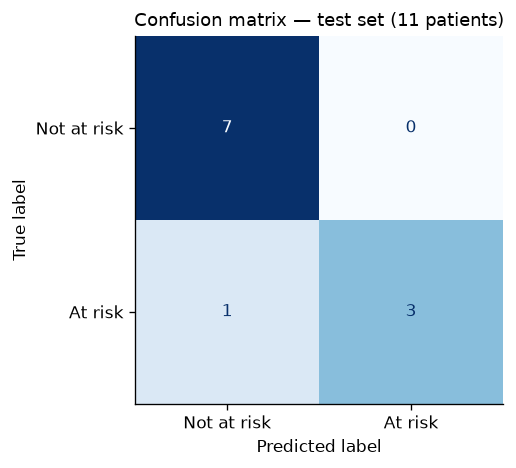


In plain English:
  Correctly identified as NOT at risk: 7
  Correctly identified as AT RISK:     3
  Healthy patients wrongly flagged:    0  (false alarms)
  At-risk patients missed:             1  (dangerous misses)


In [14]:
# A confusion matrix shows exactly which patients were
# correctly classified and which were misclassified.
#
#                  Predicted Not at risk | Predicted At risk
# Actual Not at risk:   True Negatives  |  False Positives
# Actual At risk:       False Negatives |  True Positives
#
# False Negatives (bottom-left) are the dangerous ones —
# these are sick patients the model missed.

fig, ax = plt.subplots(figsize=(5, 4))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not at risk", "At risk"]
)
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Confusion matrix — test set (11 patients)", fontsize=11)

plt.tight_layout()
plt.savefig("../data/confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

# Print in plain English
tn, fp, fn, tp = cm.ravel()
print(f"\nIn plain English:")
print(f"  Correctly identified as NOT at risk: {tn}")
print(f"  Correctly identified as AT RISK:     {tp}")
print(f"  Healthy patients wrongly flagged:    {fp}  (false alarms)")
print(f"  At-risk patients missed:             {fn}  (dangerous misses)")

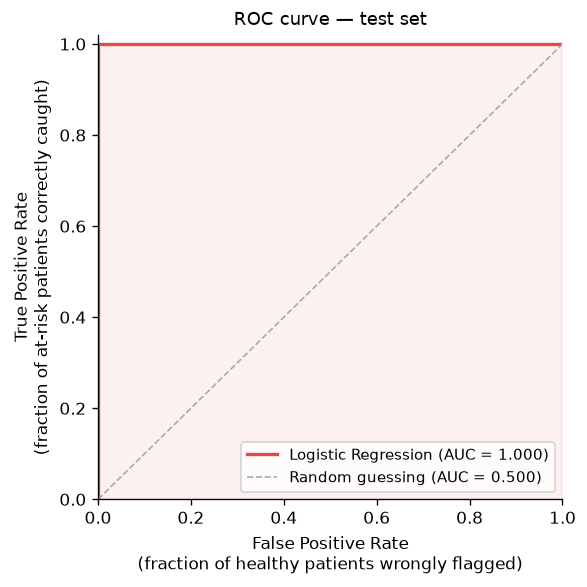

In [15]:
# The ROC curve shows the trade-off between catching sick patients
# (recall/sensitivity) and avoiding false alarms (specificity)
# at every possible decision threshold.
#
# The closer the curve hugs the top-left corner, the better.
# AUC = area under this curve. 1.0 is perfect, 0.5 is random.

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
auc = roc_auc_score(y_test, y_pred_proba)

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(fpr, tpr, color="#E24B4A", linewidth=2,
        label=f"Logistic Regression (AUC = {auc:.3f})")
ax.plot([0, 1], [0, 1], color="#AAAAAA", linestyle="--",
        linewidth=1, label="Random guessing (AUC = 0.500)")
ax.fill_between(fpr, tpr, alpha=0.08, color="#E24B4A")
ax.set_xlabel("False Positive Rate\n(fraction of healthy patients wrongly flagged)", fontsize=10)
ax.set_ylabel("True Positive Rate\n(fraction of at-risk patients correctly caught)", fontsize=10)
ax.set_title("ROC curve — test set", fontsize=11)
ax.legend(fontsize=9)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])

plt.tight_layout()
plt.savefig("../data/roc_curve.png", dpi=150, bbox_inches="tight")
plt.show()

Feature coefficients (what the model learned):
Positive = pushes towards AT RISK
Negative = pushes towards NOT AT RISK

          feature  coefficient
  rr_pct_abnormal     1.533578
spo2_pct_below_95     1.183287
           rr_std     0.352443
           rr_max     0.289182
  rr_pct_above_25     0.208087
              age     0.175480
        rr_median     0.172874
          rr_mean     0.136856
spo2_pct_below_92     0.054381
          hr_mean     0.036103
           gender    -0.340548
           hr_std    -0.377753
         spo2_std    -0.514830
        spo2_mean    -0.589129
      spo2_median    -0.605685
         spo2_min    -0.614730
           rr_min    -0.660759


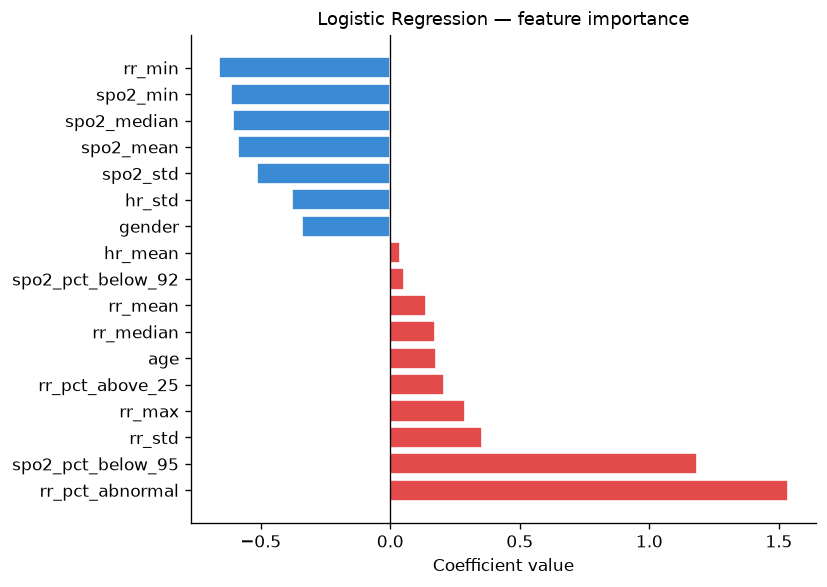

In [16]:
# Logistic Regression assigns a weight (coefficient) to each feature.
# A large positive weight means higher values of that feature push
# the model towards predicting "at risk".
# A large negative weight pushes towards "not at risk".

# Extract the coefficients from inside the pipeline
scaler = best_model.named_steps["scaler"]
clf    = best_model.named_steps["clf"]

coef_df = pd.DataFrame({
    "feature":     FEATURE_COLS,
    "coefficient": clf.coef_[0]
}).sort_values("coefficient", ascending=False)

print("Feature coefficients (what the model learned):")
print("Positive = pushes towards AT RISK")
print("Negative = pushes towards NOT AT RISK")
print()
print(coef_df.to_string(index=False))

# Plot it
fig, ax = plt.subplots(figsize=(7, 5))
colors = ["#E24B4A" if c > 0 else "#3B8BD4" for c in coef_df["coefficient"]]
ax.barh(coef_df["feature"], coef_df["coefficient"], color=colors, edgecolor="white")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Coefficient value", fontsize=10)
ax.set_title("Logistic Regression — feature importance", fontsize=11)
plt.tight_layout()
plt.savefig("../data/feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

In [17]:
import joblib

# Export your trained pipeline model to a file
joblib.dump(best_model, '../data/respiratory_risk_model.pkl')
print("Model exported successfully!")

Model exported successfully!
